# Sprint 2: Model Building & Evaluation
- Build baseline and compare multiple classification models on the Bridge Condition dataset.

## Imports & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("./final_bridge_data")
print("Shape:", df.shape)
df.head()

Shape: (592, 10)


,Age_of_Bridge,Traffic_Volume,Bridge_Condition,Material_Type_Concrete,Maintenance_Level_Annual,Maintenance_Level_No-Maintainance,Material_Type_Steel_0,Material_Type_Steel_1,Maintenance_Level_Bi-Annual_0,Maintenance_Level_Bi-Annual_1
0,80,60,0,1,0,1,1,0,1,0
1,44,2516,0,0,0,0,0,1,0,1
2,61,4406,1,1,1,0,1,0,1,0
3,93,2082,1,0,0,1,0,1,1,0
4,62,4159,0,0,0,1,0,1,1,0


## Observation
- The `final_bridge_data` is the cleaned and encoded output from Sprint 1.
- It contains **592 rows** and **8 columns** (7 features + 1 target).
- Target `Bridge_Condition`: **0 = Good/Safe**, **1 = Poor/Unsafe** (imbalanced — ~83% class 0, ~17% class 1).

---
## Step 1: Baseline Model
-  Establish a performance baseline using Logistic Regression before trying complex models.

In [3]:
X = df.drop('Bridge_Condition', axis=1)
y = df['Bridge_Condition']

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y )

num_cols = ['Age_of_Bridge', 'Traffic_Volume']
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

print("Train size:", X_train.shape)
print("Test size: ", X_test.shape)
print("Class distribution (train):")
print(y_train.value_counts())

Train size: (473, 9)
Test size:  (119, 9)
Class distribution (train):
Bridge_Condition
0    392
1     81
Name: count, dtype: int64


In [4]:
# Baseline: Logistic Regression
baseline_model = LogisticRegression(random_state=42)
baseline_model.fit(X_train, y_train)

y_pred_base = baseline_model.predict(X_test)

print("=== Baseline Model: Logistic Regression ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_base):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_base, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_base, zero_division=0):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_base, zero_division=0):.4f}")
print()
print(classification_report(y_test, y_pred_base, zero_division=0))

=== Baseline Model: Logistic Regression ===
Accuracy : 0.8235
Precision: 0.4667
Recall   : 0.3500
F1 Score : 0.4000

              precision    recall  f1-score   support

           0       0.88      0.92      0.90        99
           1       0.47      0.35      0.40        20

    accuracy                           0.82       119
   macro avg       0.67      0.63      0.65       119
weighted avg       0.81      0.82      0.81       119



## Observation
- Logistic Regression gives us the baseline performance.
- Due to class imbalance, accuracy alone is misleading — Recall and F1 are the key metrics here.
- The baseline model will be beaten by more powerful ensemble methods.

---
## Step 2: Train Multiple Models

- Logistic Regression, Decision Tree, Random Forest, SVM, Naive Bayes, Gradient Boosting

In [5]:
models = {
    "Logistic Regression" : LogisticRegression(random_state=42),
    "Decision Tree" : DecisionTreeClassifier(random_state=42),
    "Random Forest" : RandomForestClassifier(random_state=42),
    "SVM" : SVC(random_state=42),
    "Naive Bayes" : GaussianNB(),
    "Gradient Boosting" : GradientBoostingClassifier(random_state=42),
}

results = {}

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred  = model.predict(X_test)

    results[name] = {
        "model" : model,
        "y_test_pred" : y_test_pred,
        "train_accuracy" : accuracy_score(y_train, y_train_pred),
        "test_accuracy" : accuracy_score(y_test,  y_test_pred),
        "precision" : precision_score(y_test, y_test_pred, zero_division=0),
        "recall" : recall_score(y_test, y_test_pred, zero_division=0),
        "f1" : f1_score(y_test, y_test_pred, zero_division=0),
    }
    print(f"{name} trained.")

Logistic Regression trained.
Decision Tree trained.
Random Forest trained.
SVM trained.
Naive Bayes trained.
Gradient Boosting trained.


In [6]:
results

{'Logistic Regression': {'model': LogisticRegression(random_state=42),
  'y_test_pred': array([0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
         1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
         1, 0, 0, 0, 0, 0, 0, 0, 0]),
  'train_accuracy': 0.8477801268498943,
  'test_accuracy': 0.8235294117647058,
  'precision': 0.4666666666666667,
  'recall': 0.35,
  'f1': 0.4},
 'Decision Tree': {'model': DecisionTreeClassifier(random_state=42),
  'y_test_pred': array([0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
         1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
         0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0

---
## Step 3: Model Evaluation

### Classification Metrics: Accuracy, Precision, Recall, F1 Score

In [7]:
# Summary table
summary = []
for name, res in results.items():
    summary.append({
        "Model" : name,
        "Train Accuracy": round(res["train_accuracy"], 4),
        "Test Accuracy" : round(res["test_accuracy"], 4),
        "Precision" : round(res["precision"], 4),
        "Recall" : round(res["recall"], 4),
        "F1 Score" : round(res["f1"], 4),
    })

summary_df = pd.DataFrame(summary).set_index("Model")
summary_df

,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score
Model,,,,,
Logistic Regression,0.8478,0.8235,0.4667,0.35,0.4000
Decision Tree,1.0000,0.8487,0.5417,0.65,0.5909
Random Forest,1.0000,0.8992,0.7000,0.70,0.7000
SVM,0.8689,0.8571,0.6364,0.35,0.4516
Naive Bayes,0.8584,0.8403,0.5333,0.40,0.4571
Gradient Boosting,0.9852,0.8655,0.5833,0.70,0.6364


### Confusion Matrices

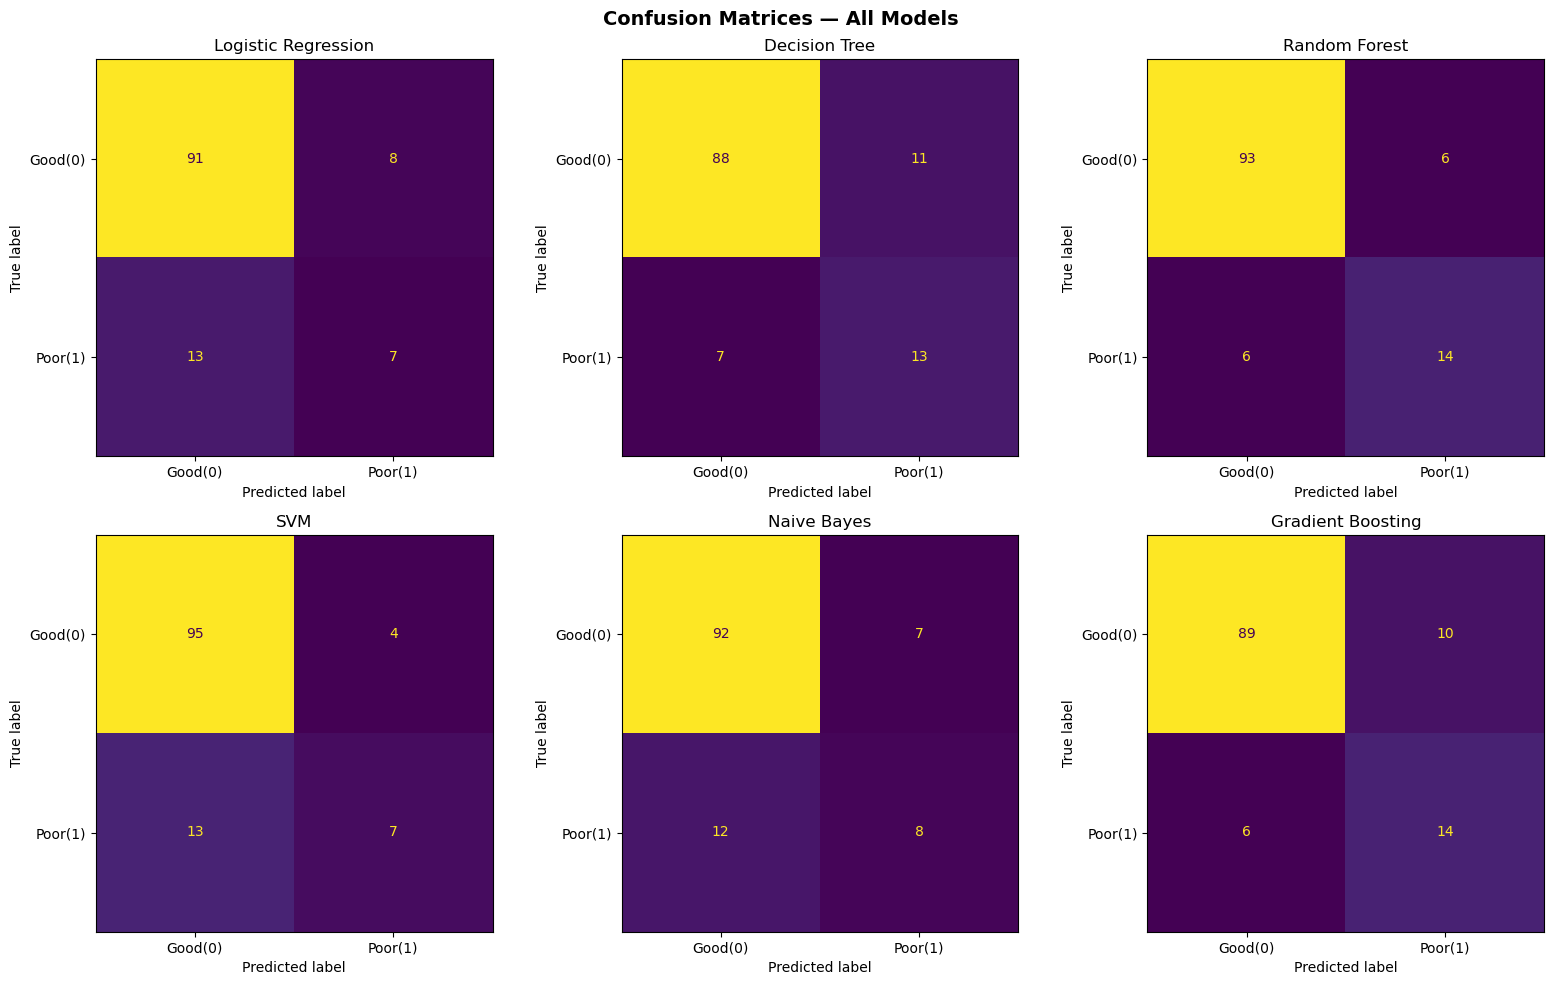

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res["y_test_pred"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Good(0)", "Poor(1)"])
    disp.plot(ax=axes[i], colorbar=False)
    axes[i].set_title(name)

plt.suptitle("Confusion Matrices — All Models", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Observation
- **Random Forest** and **Gradient Boosting** tend to capture the minority class (Poor bridges) better.
- **Naive Bayes** may struggle due to the feature independence assumption.
- Look at Recall for class 1 (Poor) — missing a "Poor" bridge is more costly than a false alarm.

---
## Step 4: Overfitting & Underfitting Check

- Compare Training Accuracy vs Testing Accuracy

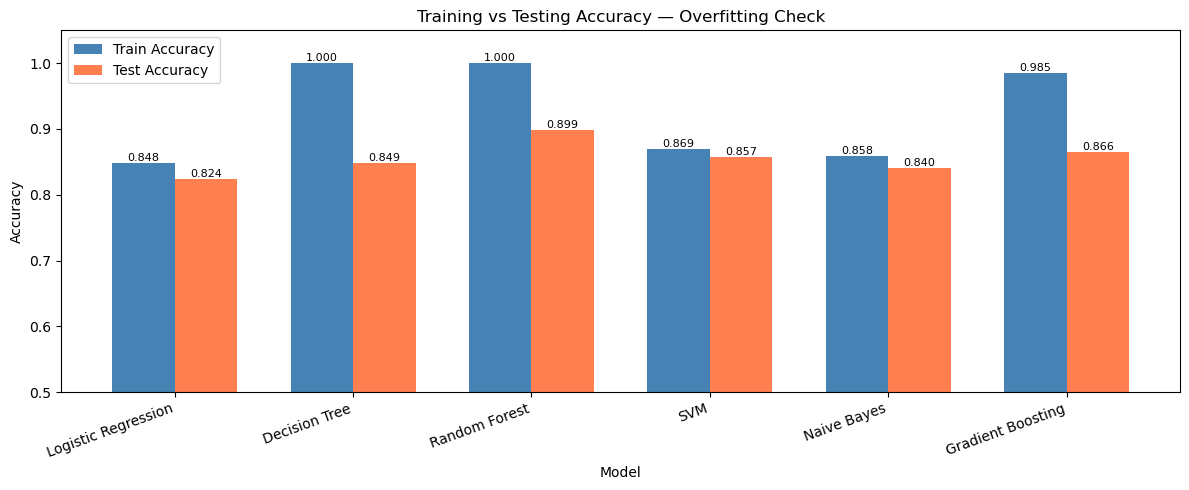

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))

model_names  = list(results.keys())
train_scores = [results[m]["train_accuracy"] for m in model_names]
test_scores  = [results[m]["test_accuracy"]  for m in model_names]

x = np.arange(len(model_names))
width = 0.35

bars1 = ax.bar(x - width/2, train_scores, width, label='Train Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, test_scores,  width, label='Test Accuracy',  color='coral')

ax.set_xlabel('Model')
ax.set_ylabel('Accuracy')
ax.set_title('Training vs Testing Accuracy — Overfitting Check')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=20, ha='right')
ax.set_ylim(0.5, 1.05)
ax.legend()
ax.bar_label(bars1, fmt='%.3f', fontsize=8)
ax.bar_label(bars2, fmt='%.3f', fontsize=8)

plt.tight_layout()
plt.show()

## Observation
- If **Train Accuracy >> Test Accuracy** → model is **overfitting** (memorising training data).
- If both are low → model is **underfitting**.
- Decision Tree with default depth often overfits; Random Forest generalises better due to bagging.

---
## Step 5: Model Comparison Table

In [10]:
comparison_rows = []
for name, res in results.items():
    gap       = res["train_accuracy"] - res["test_accuracy"]
    overfit   = "Yes" if gap > 0.05 else "No"
    if gap > 0.10:
        remark = "High overfitting — needs pruning or regularization"
    elif gap > 0.05:
        remark = "Mild overfitting"
    elif res["test_accuracy"] < 0.75:
        remark = "Underfitting — model too simple"
    else:
        remark = "Good generalisation"

    comparison_rows.append({
        "Model"         : name,
        "F1 Score"      : round(res["f1"],            4),
        "Test Accuracy" : round(res["test_accuracy"],  4),
        "Recall (1)"    : round(res["recall"],         4),
        "Precision (1)" : round(res["precision"],      4),
        "Overfitting?"  : overfit,
        "Remarks"       : remark,
    })

comparison_df = pd.DataFrame(comparison_rows).set_index("Model")
comparison_df

,F1 Score,Test Accuracy,Recall (1),Precision (1),Overfitting?,Remarks
Model,,,,,,
Logistic Regression,0.4000,0.8235,0.35,0.4667,No,Good generalisation
Decision Tree,0.5909,0.8487,0.65,0.5417,Yes,High overfitting — needs pruning or regulariza...
Random Forest,0.7000,0.8992,0.70,0.7000,Yes,High overfitting — needs pruning or regulariza...
SVM,0.4516,0.8571,0.35,0.6364,No,Good generalisation
Naive Bayes,0.4571,0.8403,0.40,0.5333,No,Good generalisation
Gradient Boosting,0.6364,0.8655,0.70,0.5833,Yes,High overfitting — needs pruning or regulariza...
